# Project 02 — Basic Exploratory Data Analysis

**Objective:** Explore student-performance data, assess data quality, identify patterns, and communicate insights.

**Question:** Which factors appear to be most strongly associated with exam scores?

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Load the Data

In [2]:
df = pd.read_csv('student_performance.csv')
df.head()

,Student_ID,Age,Study_Hours,Attendance,Assignments_Completed,Exam_Score
0,1,18,5,85,8,62
1,2,19,8,92,10,78
2,3,18,3,70,6,55
3,4,20,10,95,10,88
4,5,19,7,88,9,74


## 3. Understand the Dataset

In [3]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.info()

Rows: 20
Columns: 6
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Student_ID             20 non-null     int64
 1   Age                    20 non-null     int64
 2   Study_Hours            20 non-null     int64
 3   Attendance             20 non-null     int64
 4   Assignments_Completed  20 non-null     int64
 5   Exam_Score             20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,20.0,10.5,5.916080,1.0,5.75,10.5,15.25,20.0
Age,20.0,19.2,1.196486,18.0,18.00,19.0,20.00,22.0
Study_Hours,20.0,7.0,3.292735,2.0,4.75,7.0,9.25,13.0
Attendance,20.0,85.2,10.440811,65.0,78.75,87.5,93.25,99.0
Assignments_Completed,20.0,8.4,1.759186,5.0,7.75,9.0,10.00,10.0
Exam_Score,20.0,73.2,14.616501,48.0,61.25,75.0,86.50,95.0


## 4. Data Quality Checks

In [5]:
print('Missing values:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
Student_ID               0
Age                      0
Study_Hours              0
Attendance               0
Assignments_Completed    0
Exam_Score               0
dtype: int64

Duplicate rows: 0


### Data quality interpretation

The dataset contains no missing values and no duplicate rows. The variables also use appropriate numerical data types for this analysis.

## 5. Univariate Analysis

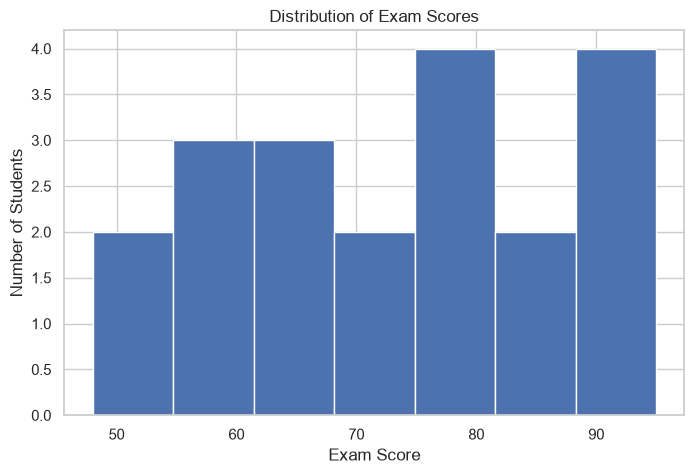

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Exam_Score'], bins=7)
ax.set_xlabel('Exam Score')
ax.set_ylabel('Number of Students')
ax.set_title('Distribution of Exam Scores')
plt.show()

The exam scores show meaningful variation between students. This makes the dataset suitable for investigating which factors are associated with performance.

## 6. Study Hours vs Exam Score

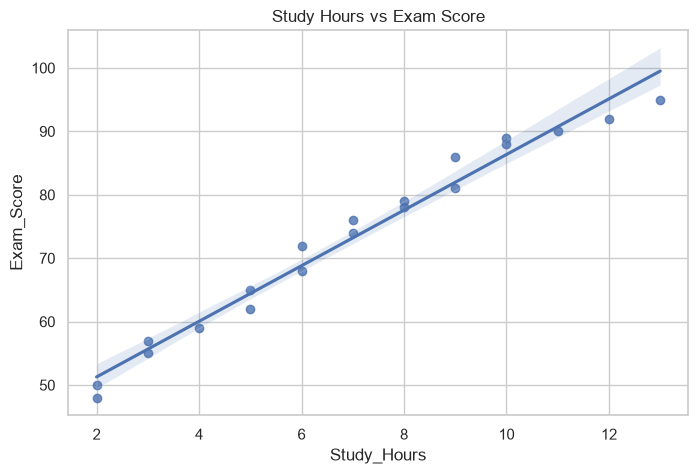

Correlation: 0.987


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='Study_Hours', y='Exam_Score', ax=ax)
ax.set_title('Study Hours vs Exam Score')
plt.show()

study_corr = df['Study_Hours'].corr(df['Exam_Score'])
print(f'Correlation: {study_corr:.3f}')

### Interpretation

The relationship is strongly positive: students who report more study hours generally have higher exam scores. This is an association rather than evidence of causation.

## 7. Attendance vs Exam Score

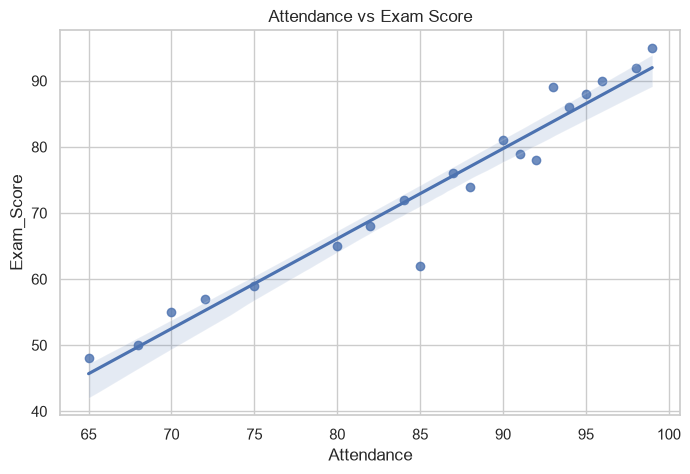

Correlation: 0.973


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='Attendance', y='Exam_Score', ax=ax)
ax.set_title('Attendance vs Exam Score')
plt.show()

attendance_corr = df['Attendance'].corr(df['Exam_Score'])
print(f'Correlation: {attendance_corr:.3f}')

## 8. Assignment Completion vs Exam Score

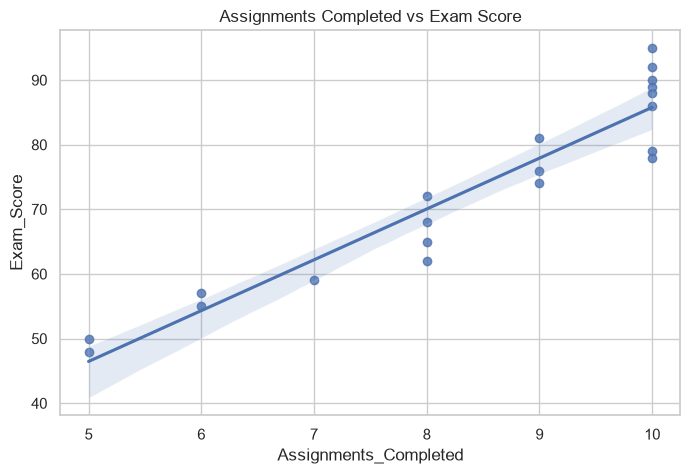

Correlation: 0.946


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='Assignments_Completed', y='Exam_Score', ax=ax)
ax.set_title('Assignments Completed vs Exam Score')
plt.show()

assignment_corr = df['Assignments_Completed'].corr(df['Exam_Score'])
print(f'Correlation: {assignment_corr:.3f}')

## 9. Correlation Analysis

In [10]:
correlation = df.drop(columns=['Student_ID']).corr()
correlation['Exam_Score'].sort_values(ascending=False)

Exam_Score               1.000000
Study_Hours              0.987493
Attendance               0.972977
Assignments_Completed    0.946475
Age                      0.912482
Name: Exam_Score, dtype: float64

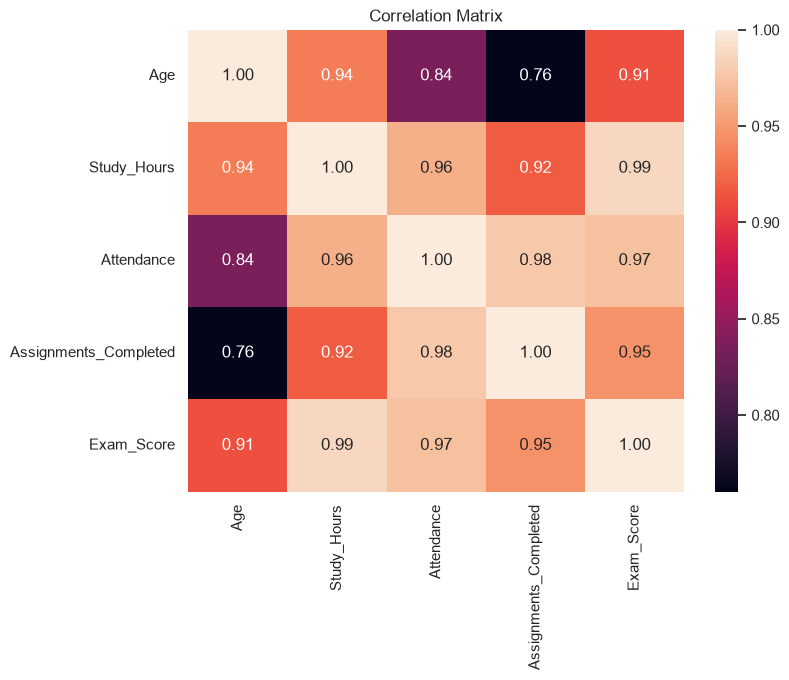

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

## 10. Outlier Investigation

A boxplot provides a quick visual check for unusually high or low observations.

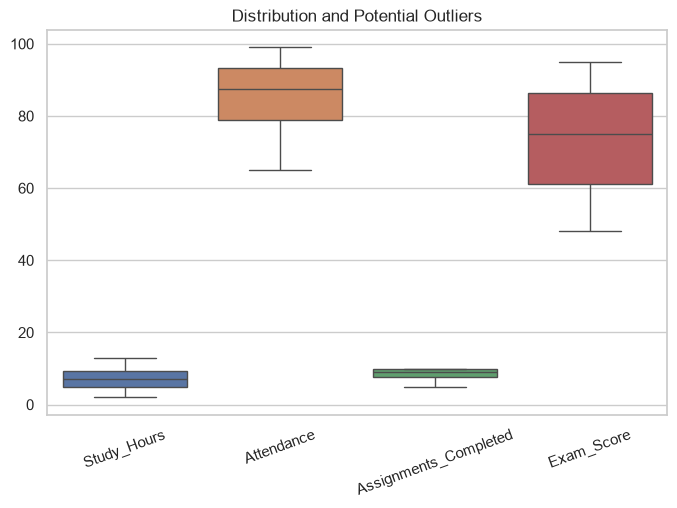

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df[['Study_Hours', 'Attendance', 'Assignments_Completed', 'Exam_Score']], ax=ax)
ax.set_title('Distribution and Potential Outliers')
plt.xticks(rotation=20)
plt.show()

## 11. Key Findings

1. The dataset has 20 observations and 6 variables.
2. No missing values or duplicate rows were detected.
3. Exam performance varies substantially between students.
4. Study hours, attendance, and assignment completion are positively associated with exam scores.
5. Study hours show the strongest association with exam score among the main performance variables.
6. Correlation does not imply causation.

## 12. Next Steps

The next logical project is to build a **linear regression model** to predict exam scores and evaluate its performance using appropriate train/test splitting and regression metrics.